# EDA: Animals-10 Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("alessiocorrado99/animals10")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 586M/586M [00:28<00:00, 21.6MB/s] 

Extracting files...


## 1. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = os.path.join(path, "raw-img")

print(f"Dataset downloaded to: {path}")
print(f"Images directory: {data_dir}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/zaharguzij/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2
Images directory: /Users/zaharguzij/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img


In [10]:
classes = os.listdir(os.path.join(path, 'raw-img'))
print("Classes in the dataset:")
for cls in classes:
    print(f"- {cls}")  

Classes in the dataset:
- gallina
- ragno
- gatto
- farfalla
- mucca
- cavallo
- cane
- pecora
- scoiattolo
- elefante


So, it is in italian, we need to do mapping

In [11]:
LABEL_MAP = {
    "gallina":    "chicken",
    "ragno":      "spider",
    "gatto":      "cat",
    "farfalla":   "butterfly",
    "mucca":      "cow",
    "cavallo":    "horse",
    "cane":       "dog",
    "pecora":     "sheep",
    "scoiattolo": "squirrel",
    "elefante":   "elephant",
}

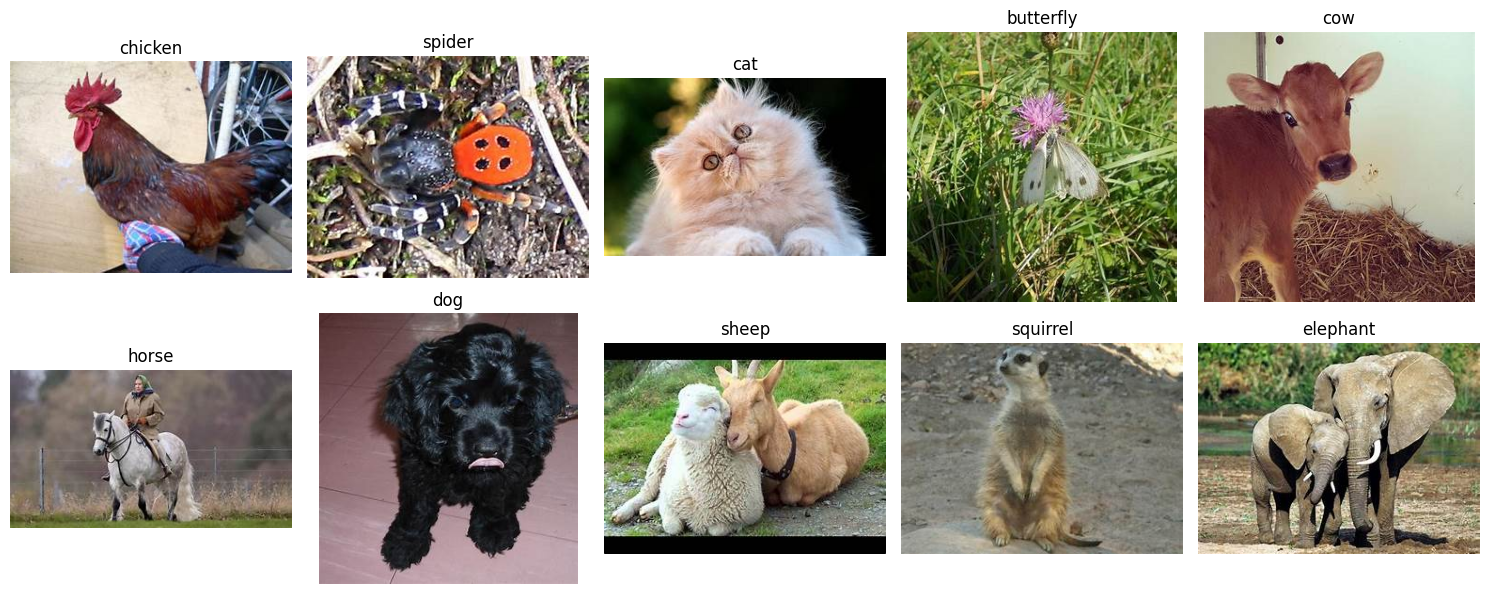

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (folder, label) in zip(axes.flat, LABEL_MAP.items()):
    folder_path = os.path.join(data_dir, folder)
    img_file = os.listdir(folder_path)[0]
    img = Image.open(os.path.join(folder_path, img_file))
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

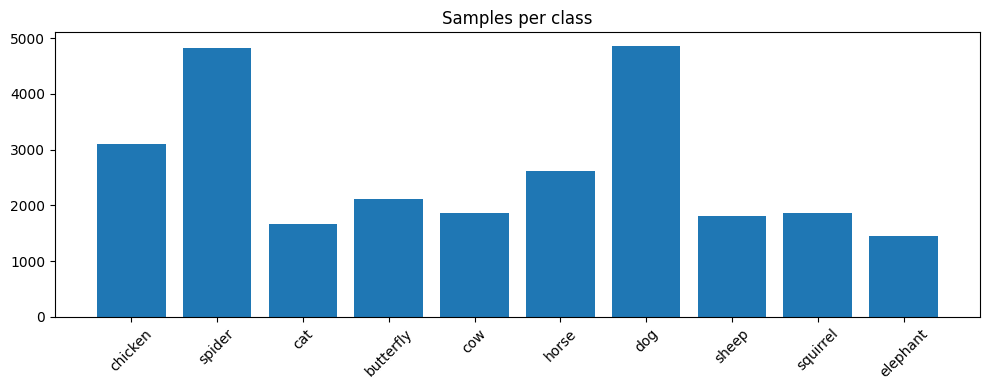

In [16]:
class_counts = {
    LABEL_MAP[cls]: len(os.listdir(os.path.join(data_dir, cls)))
    for cls in os.listdir(data_dir)
}

plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Samples per class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

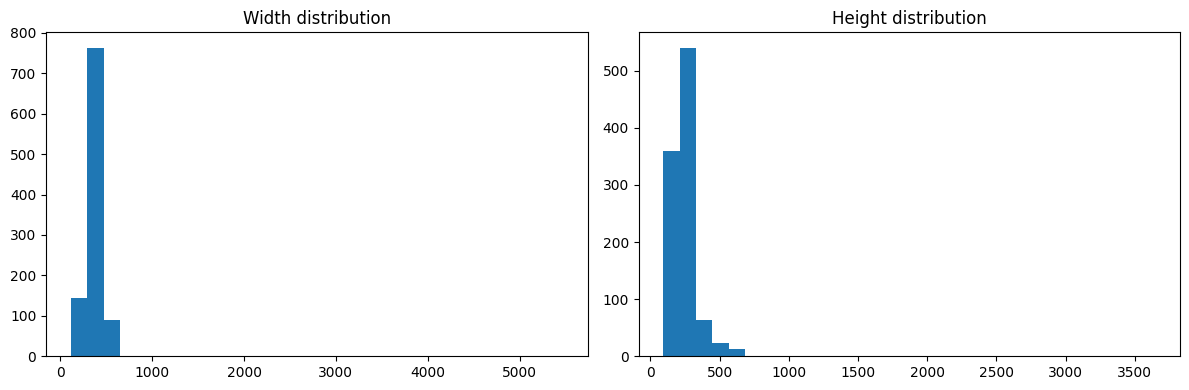

Mean size: 333 x 260
Min size:  112 x 92
Max size:  5472 x 3648


In [19]:
widths, heights = [], []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    for img_file in os.listdir(folder_path)[:100]:  # 100 на клас достатньо
        try:
            img = Image.open(os.path.join(folder_path, img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            continue

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30)
axes[0].set_title("Width distribution")
axes[1].hist(heights, bins=30)
axes[1].set_title("Height distribution")
plt.tight_layout()
plt.show()

print(f"Mean size: {np.mean(widths):.0f} x {np.mean(heights):.0f}")
print(f"Min size:  {min(widths)} x {min(heights)}")
print(f"Max size:  {max(widths)} x {max(heights)}")

In [20]:
total = sum(class_counts.values())
print(f"Total images: {total}\n")
for label, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{label:<12} {count:>5}  ({100 * count / total:.1f}%)")

Total images: 26179

dog           4863  (18.6%)
spider        4821  (18.4%)
chicken       3098  (11.8%)
horse         2623  (10.0%)
butterfly     2112  (8.1%)
cow           1866  (7.1%)
squirrel      1862  (7.1%)
sheep         1820  (7.0%)
cat           1668  (6.4%)
elephant      1446  (5.5%)


In [21]:
max_count = max(class_counts.values())
min_count = min(class_counts.values())
print(f"Imbalance ratio: {max_count / min_count:.1f}x")

Imbalance ratio: 3.4x


So, it is need, when we wiill be trainng classificator to add waiths to porbabilities, that images from class get into batches